# **1. Data loading**

1. install and load the required library
2. check the GPU is available
3. load the data file

In [ ]:
!pip install torchmetrics optuna

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
train_img_dir = Path("/content/drive/MyDrive/dataset/train/images")
test_img_dir  = Path("/content/drive/MyDrive/dataset/val/images")


In [ ]:
!nvidia-smi

Thu Apr  9 13:43:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset , DataLoader
import torch.nn.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn ,FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datasets import load_dataset
import cv2 as cv
import numpy as np
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from plotly.subplots import make_subplots
import optuna.visualization as ov
from torch.optim import Adam, AdamW , SGD
import optuna
from pycocotools.coco import COCO


In [ ]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip
!pip install pycocotools

--2026-04-09 13:43:23--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.123.177, 3.5.20.157, 52.216.220.57, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.123.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: â€˜annotations_trainval2017.zipâ€™

annotations_trainva 100%[===================>] 241.19M  96.3MB/s    in 2.5s    

2026-04-09 13:43:26 (96.3 MB/s) - â€˜annotations_trainval2017.zipâ€™ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: annotations/instances_train2017.json  
  inflating: annotations/instances_val2017.json  
  inflating: annotations/captions_train2017.json  
  inflating: annotations/captions_val2017.json  
  inflating: annotations/person_keypoints_train2017.json  
  inflating: annotations/person_keypoints_val2017.json  


# **2. Data cleaning**

1. do the data cleaning for coco , get the data that only contains the person

In [ ]:
from pycocotools.coco import COCO

coco = COCO('annotations/instances_train2017.json')
coco_test = COCO('annotations/instances_val2017.json')

cat_ids = coco.getCatIds(catNms=['person'])
test_cat_ids = coco_test.getCatIds(catNms=['person'])

loading annotations into memory...
Done (t=12.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.55s)
creating index...
index created!


# **3. Data preprocessing**

1. change the device type
2. load the data by index
3. split data train 2000 and test only 500
4. load the sample of data
5. load image of data
6. define transformation matrix

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
img_ids = coco.getImgIds(catIds=cat_ids)
test_img_ids = coco_test.getImgIds(catIds=test_cat_ids)

print("train total from annotation:", len(img_ids))
print("test total from annotation :", len(test_img_ids))

train total from annotation: 64115
test total from annotation : 2693


In [ ]:
train_img_ids = img_ids[:2000]
test_img_ids = img_ids[2000:2500]

In [ ]:
train_files = set(os.listdir(train_img_dir))
test_files = set(os.listdir(test_img_dir))

train_img_ids = []
test_img_ids = []


for img_id in coco.getImgIds():
    file_name = coco.loadImgs(img_id)[0]['file_name']

    if file_name in train_files:
        train_img_ids.append(img_id)
for img_id in coco_test.getImgIds():
    file_name = coco_test.loadImgs(img_id)[0]['file_name']

    if file_name in test_files:
        test_img_ids.append(img_id)
print("Sample COCO file:", file_name)
print("train_img_ids:", len(train_img_ids))
print("test_img_ids :", len(test_img_ids))
print(list(test_files)[:10])

Sample COCO file: 000000015335.jpg
train_img_ids: 4999
test_img_ids : 500
['000000057597.jpg', '000000558213.jpg', '000000099182.jpg', '000000295316.jpg', '000000369675.jpg', '000000558421.jpg', '000000033638.jpg', '000000385190.jpg', '000000369503.jpg', '000000410496.jpg']


In [ ]:
train_imgs = coco.loadImgs(train_img_ids)
test_imgs = coco_test.loadImgs(test_img_ids)

In [ ]:
train_img_ids = train_img_ids[:2000]
test_img_ids  = test_img_ids[:500]

In [ ]:
train_imgs[0] ,test_imgs[0]

({'license': 2,
  'file_name': '000000005802.jpg',
  'coco_url': 'http://images.cocodataset.org/train2017/000000005802.jpg',
  'height': 479,
  'width': 640,
  'date_captured': '2013-11-14 17:28:25',
  'flickr_url': 'http://farm4.staticflickr.com/3810/9614287841_1b724dbbc5_z.jpg',
  'id': 5802},
 {'license': 1,
  'file_name': '000000017627.jpg',
  'coco_url': 'http://images.cocodataset.org/val2017/000000017627.jpg',
  'height': 480,
  'width': 640,
  'date_captured': '2013-11-16 15:13:53',
  'flickr_url': 'http://farm5.staticflickr.com/4145/4977243989_c2efb1b911_z.jpg',
  'id': 17627})

In [ ]:
def get_boxes_labels(coco, img_id):
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=[1])
    anns = coco.loadAnns(ann_ids)

    boxes = []
    labels = []

    for ann in anns:
        x, y, w, h = ann['bbox']
        boxes.append([x, y, x + w, y + h])
        labels.append(1)

    return boxes, labels

In [ ]:
img_id = train_img_ids[0]

boxes, labels = get_boxes_labels(coco, img_id)

print(boxes)
print(labels)

[[15.04, 73.03, 291.05, 471.48], [391.68, 179.4, 478.12, 452.65]]
[1, 1]


In [ ]:
class CocoPersonDataset(Dataset):
  def __init__(self,coco , img_ids , img_dir , transforms=None):
    self.img_ids = img_ids
    self.img_dir = img_dir
    self.coco = coco
    self.transforms = transforms

  def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert("RGB")


        img_np = np.array(img)

        boxes, labels = get_boxes_labels(self.coco, img_id)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            augmented = self.transforms(
                image=img_np,
                bboxes=boxes,
                labels=labels,
            )

            img = augmented['image']
            boxes = list(augmented['bboxes'])
            labels = list(augmented['labels'])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }


        return img, target

  def __len__(self):
        return len(self.img_ids)


In [ ]:
train_dataset = CocoPersonDataset(coco , train_img_ids ,img_dir=train_img_dir)
test_dataset = CocoPersonDataset(coco_test , test_img_ids ,img_dir=test_img_dir)

In [ ]:
def load_image(train_dataset):
  fig, axs = plt.subplots(2, 2, figsize=(10, 10))

  for i, ax in enumerate(axs.flatten()):
      random_idx = torch.randint(0, len(train_dataset), (1,)).item()

      img, target = train_dataset[random_idx]

      img_np = np.array(img)
      img_cv = cv.cvtColor(img_np, cv.COLOR_RGB2BGR)

      for box in target['boxes']:
          x1, y1, x2, y2 = map(int , box)

          cv.rectangle(img_cv, (x1 , y1) , (x2 , y2) , (255, 0 ,0 ), 2)

      img_display = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)

      ax.imshow(img_display)
      ax.axis('off')
      ax.set_title(f"Image ID: {target['boxes'].shape[0]} person(s)")

  plt.tight_layout()
  plt.show()

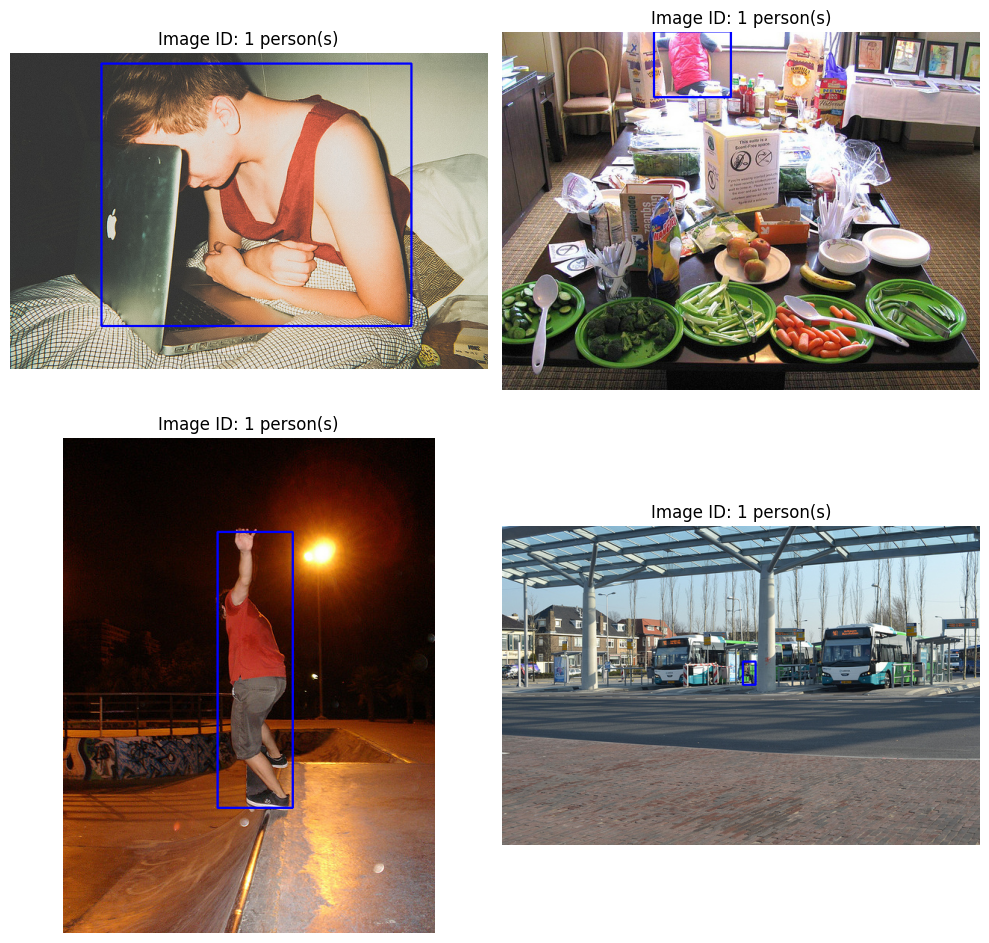

In [ ]:
load_image(train_dataset)

In [ ]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 160M/160M [00:00<00:00, 224MB/s]


In [ ]:
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['labels'],
    min_visibility=0.3,
))

val_aug = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

In [ ]:
train_dataset.transforms = train_aug
test_dataset.transforms = val_aug

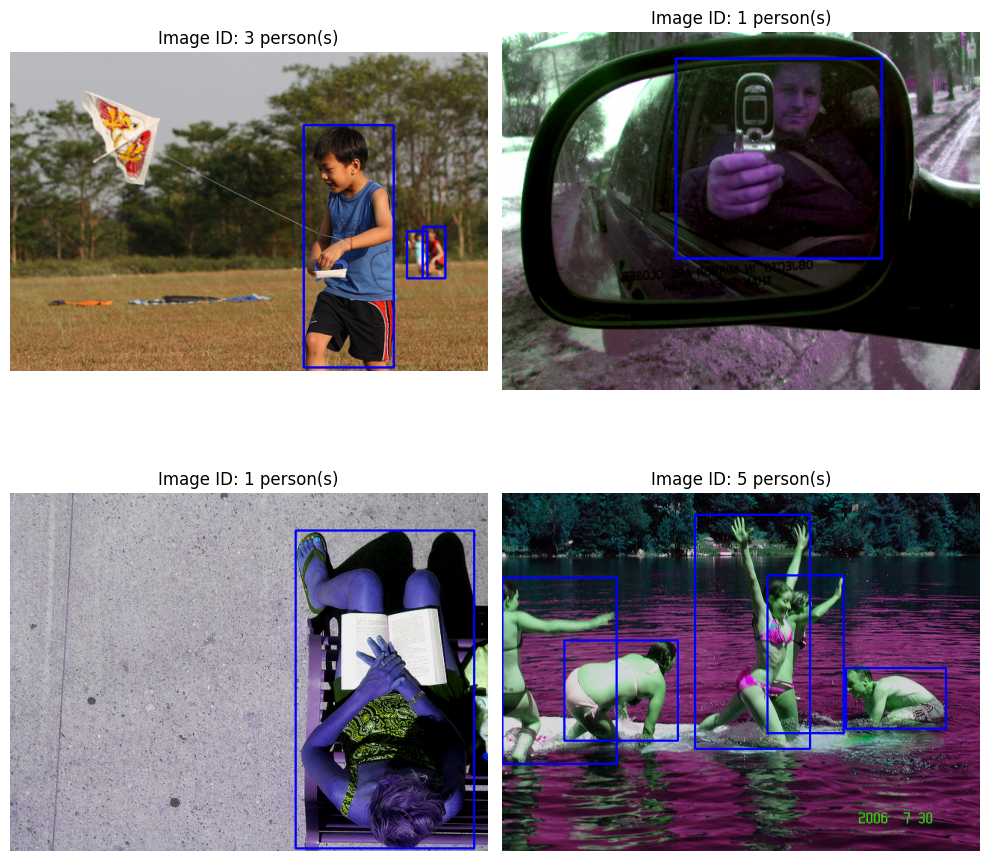

In [ ]:
def load_image(dataset):
  fig, axs = plt.subplots(2, 2, figsize=(10, 10))

  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])

  for i, ax in enumerate(axs.flatten()):
      random_idx = torch.randint(0, len(dataset), (1,)).item()

      img, target = dataset[random_idx]

      img_np = img.numpy()
      img_np = img_np.transpose(1, 2, 0)
      img_np = std * img_np + mean
      img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

      img_cv = cv.cvtColor(img_np, cv.COLOR_RGB2BGR)


      if target['boxes'].shape[0] > 0:
          boxes_list = target['boxes'].tolist()
          for box in boxes_list:
              x1, y1, x2, y2 = map(int, box)
              cv.rectangle(img_cv, (x1, y1), (x2, y2), (255, 0, 0), 2)

      img_display = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)

      ax.imshow(img_display)
      ax.axis('off')
      ax.set_title(f"Image ID: {target['boxes'].shape[0]} person(s)")

  plt.tight_layout()
  plt.show()

load_image(train_dataset)

# **4. Data modeling**

1. define data loader
2. define the matrices that will be used
3. define train and test function
4. load the model that will be used

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

In [ ]:
for param in model.backbone.parameters():
    param.requires_grad_(True)

In [ ]:
mean_ap = MeanAveragePrecision()

In [ ]:
def train_step(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0
    all_preds   = []
    all_targets = []

    for i ,(X, y) in enumerate(dataloader):

        images  = [img.to(device) for img in X]
        targets = [{k: v.to(device) for k, v in t.items()} for t in y]

        filtered = [(img, t) for img, t in zip(images, targets) if t["boxes"].numel() > 0]
        if not filtered:

            continue

        filtered_images, filtered_targets = zip(*filtered)

        optimizer.zero_grad()
        loss_dict = model(list(filtered_images), list(filtered_targets))

        if not isinstance(loss_dict, dict) or not loss_dict:
            continue

        loss = sum(loss_dict.values())
        loss.backward()
        optimizer.step()


        total_loss += loss.item()

        num_batches += 1

        model.eval()
        with torch.no_grad():
            preds = model(images)
            all_preds.extend(preds)
            all_targets.extend(targets)
        model.train()

    mean_ap.reset()
    mean_ap.update(all_preds, all_targets)

    return total_loss / max(1, num_batches), mean_ap.compute()

In [ ]:
def eval_step(model, dataloader, device):
    total_loss = 0.0
    num_batches = 0

    model.train()
    with torch.no_grad():
        for i , (X, y) in enumerate(dataloader):
            images  = [img.to(device) for img in X]
            targets = [{k: v.to(device) for k, v in t.items()} for t in y]

            loss_dict = model(images, targets)
            if isinstance(loss_dict, dict) and loss_dict:
                total_loss += sum(loss_dict.values()).item()
                num_batches += 1

    mean_ap.reset()
    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            images  = [img.to(device) for img in X]
            targets = [{k: v.to(device) for k, v in t.items()} for t in y]
            preds   = model(images)
            mean_ap.update(preds, targets)

    return total_loss / max(1, num_batches), mean_ap.compute()

In [ ]:
def train(model, train_dataloader, test_dataloader, optimizer, device, epochs, patience=5):
    patience_counter = 0
    best_score = 0

    for epoch in range(1, epochs + 1):
        print("start testing at epoch" , epoch)
        train_loss, train_map = train_step(model, train_dataloader, optimizer, device)
        test_loss,  test_map  = eval_step(model, test_dataloader, device)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{epochs}] "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {test_loss:.4f} | "
                  f"Train mAP@50: {train_map['map_50']:.4f} | "
                  f"Val mAP@50: {test_map['map_50']:.4f}")

        test_score = test_map['map_50'] - (0.1 * test_loss)
        if best_score < test_score:
            best_score = test_score
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  âœ“ Model saved (Val mAP@50: {test_map['map_50']:.4f}, Val Loss: {test_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  âœ— No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"Early stopping di epoch {epoch}")
            break

    return {"best_score": best_score, "test_map": test_map, "test_loss": test_loss}

# **5. Hyperparameter tuning**

1. define hyperparameter
2. start create study of tuning
3. save the best params
4. plot hyperparam tuning history

In [ ]:
import torch
from torch.optim import Adam, AdamW , SGD
import optuna

def objective(
    trial,
    train_loader,
    val_loader,
):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW" , "SGD"])

    momentum = trial.suggest_float("momentum", 0.85, 0.95)
    beta1 = trial.suggest_float("beta1", 0.9, 0.99)
    beta2 = trial.suggest_float("beta2", 0.99, 0.999)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    model = fasterrcnn_resnet50_fpn(weights=weights).to(device)
    for param in model.backbone.parameters():
        param.requires_grad_(True)

    if optimizer_name == "Adam":
        optimizer = Adam(model.parameters(), lr=learning_rate, betas=(beta1, beta2), weight_decay=weight_decay)

    elif optimizer_name == "SGD":
        optimizer = SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

    else:
        optimizer = AdamW(model.parameters(), lr=learning_rate, betas=(beta1, beta2), weight_decay=weight_decay)

    train_results_dict = train(
        model ,
        train_dataloader ,
        test_dataloader ,
        optimizer ,
        device ,
        5,
        patience=5
    )

    best_score = train_results_dict["best_score"]

    trial.report(best_score, 5)

    return best_score

In [ ]:
study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        sampler=optuna.samplers.TPESampler(seed=42),
        study_name=f"tuning_faster_rcnn"
    )

study.optimize(
    lambda trial: objective(
        trial,
        train_loader=train_dataloader,
        val_loader=test_dataloader,
    ),
    n_trials=5,
    show_progress_bar=True
)

[I 2026-04-09 13:44:28,859] A new study created in memory with name: tuning_faster_rcnn


  0%|          | 0/5 [00:00<?, ?it/s]

start testing at epoch 1
  âœ“ Model saved (Val mAP@50: 0.7076, Val Loss: 0.3761)
start testing at epoch 2
  âœ— No improvement (1/5)
start testing at epoch 3
  âœ— No improvement (2/5)
start testing at epoch 4
  âœ— No improvement (3/5)
start testing at epoch 5
  âœ— No improvement (4/5)
[I 2026-04-09 14:05:27,987] Trial 0 finished with value: 0.6700160503387451 and parameters: {'learning_rate': 3.1489116479568635e-05, 'optimizer': 'Adam', 'momentum': 0.8656018640442437, 'beta1': 0.9140395068302583, 'beta2': 0.9905227525095138, 'weight_decay': 0.0029154431891537554}. Best is trial 0 with value: 0.6700160503387451.
start testing at epoch 1
  âœ“ Model saved (Val mAP@50: 0.7346, Val Loss: 0.3354)
start testing at epoch 2
  âœ“ Model saved (Val mAP@50: 0.7444, Val Loss: 0.3307)
start testing at epoch 3
  âœ“ Model saved (Val mAP@50: 0.7498, Val Loss: 0.3286)
start testing at epoch 4
  âœ— No improvement (1/5)
start testing at epoch 5
  âœ“ Model saved (Val mAP@50: 0.7534, Val Loss: 0.329

In [ ]:
best_results = {
        "best_trial": study.best_trial,
        "best_value": study.best_value,
        "best_params": study.best_params
    }

In [ ]:
best_results['best_value'] , best_results['best_params']

(0.7204761505126953,
 {'learning_rate': 0.00025378155082656634,
  'optimizer': 'SGD',
  'momentum': 0.9332442640800421,
  'beta1': 0.9191105199610449,
  'beta2': 0.9916364247048639,
  'weight_decay': 5.415244119402541e-06})

In [ ]:
from plotly.subplots import make_subplots
import optuna.visualization as ov

plots = {
    "faster_rcnn": {
        "history":    ov.plot_optimization_history(study),
        "importance": ov.plot_param_importances(study)
    }
}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Faster RCNN - Optimization History",
        "Faster RCNN - Param Importance"
    ]
)

for model_name, figs in plots.items():
    for trace in figs["history"].data:
        fig.add_trace(trace, row=1, col=1)

    for trace in figs["importance"].data:
        fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    height=500,
    title_text="Optuna Hyperparameter Tuning Results â€” Faster RCNN"
)

fig.show()

In [ ]:
from torch.optim import SGD

optimizer = SGD(model.parameters(), lr=0.00025378155082656634, momentum=0.9332442640800421, weight_decay=5.415244119402541e-06)